# 事件驱动回测的类构建

## 0.从向量化回测到事件驱动回测

向量化回测借助 NumPy 和 pandas，代码简洁、运行迅速，是检验策略想法的便捷工具。但它有三个局限：

1. **前视偏差**：基于完整数据集运算，没有考虑新数据是逐步到达的；
2. **过度简化**：主要依赖相对收益率，难以刻画固定交易成本、固定下单金额、股票不可分割等现实细节；
3. **非递归性**：无法处理依赖盈亏等状态变量的路径依赖型策略。

事件驱动回测按"新数据逐步到达"的方式逐条处理，每一次新数据（如一根 K 线、一个新收盘价、利率变动或触发止损）就是一个事件。其优点：

- **增量方式**：与真实交易一致，新数据逐步到达；
- **真实的建模**：可自由定义各类事件触发的处理逻辑；
- **路径依赖**：方便跟踪迄今最高价/最低价等路径依赖统计量；
- **可复用性**：通过面向对象编程统一基础功能；
- **贴近交易**：部分组件可直接用于策略的自动化实盘。

本章中，一个事件通常由一根 K 线标识，例如 1 分钟 K 线（日内策略）或日 K 线（基于每日收盘价的策略）。

本章结构：先介绍回测基类 `BacktestBase`，再基于它实现做多和做空两种回测类。本 notebook 涵盖回测基类部分。

## 1. 回测基类：设计要求

构建事件驱动回测的 Python 类，需满足以下要求：

| 要求 | 说明 |
|---|---|
| 数据获取与准备 | 基类负责数据读取及回测前的准备。为聚焦主题，本 notebook 仅支持从 CSV 读取的日终（EOD）数据 |
| 辅助与便捷函数 | 如绘制数据、打印状态变量、返回某根 K 线的日期和价格 |
| 下单 | 本 notebook 仅建模基本的市价买入/卖出订单 |
| 平仓 | 回测结束时，所有持仓都需平掉，由基类完成这最后一笔交易 |

满足这些要求后，基于简单移动平均线、动量、均值回归以及机器学习预测的策略回测类都可以在其上构建。

## 2. 基类代码：`BacktestBase`

> 相对原书代码，做了两处小改动：
> 1. `place_buy_order` 中的输出原文误写为 `selling`，已改为 `buying`；
> 2. 新版 Matplotlib（≥ 3.6）已不再提供 `'seaborn'` 样式名，这里加了回退处理。

同目录另有可 import 的 `BacktestBase.py`（与下方类代码同步），供 `long_only_backtesting.ipynb` 等脚本使用。


In [54]:
import os
proxy = 'http://127.0.0.1:7897'
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [55]:
#
# Python Script with Base Class
# for Event-Based Backtesting
#
# Python for Algorithmic Trading
# (c) Dr. Yves J. Hilpisch
# The Python Quants GmbH
#
import numpy as np
import pandas as pd
from pylab import mpl, plt

try:
    plt.style.use('seaborn')            # 旧版 Matplotlib
except OSError:
    plt.style.use('seaborn-v0_8')       # 新版 Matplotlib
mpl.rcParams['font.family'] = 'serif'

In [56]:
class BacktestBase(object):
    '''事件驱动回测的基类。'''

    def __init__(self, symbol, start, end, amount,
                 ftc=0.0, ptc=0.0, verbose=True):
        '''初始化回测状态，并自动调用 get_data()。'''
        self.symbol = symbol           # TR RIC（金融标的）
        self.start = start             # 数据起始日期
        self.end = end                 # 数据结束日期
        self.initial_amount = amount   # 初始资金（保持不变）
        self.amount = amount           # 当前现金余额（一次性或按笔投入）
        self.ftc = ftc                 # 每笔固定交易成本（买/卖）
        self.ptc = ptc                 # 每笔比例交易成本（买/卖）
        self.units = 0                 # 持有数量
        self.position = 0              # 仓位：0 为市场中性
        self.trades = 0                # 交易次数
        self.verbose = verbose         # True 时输出完整信息
        self.get_data()

    def get_data(self):
        '''从 CSV 读取指定区间的 EOD 数据，并计算对数收益率。'''
        raw = pd.read_csv('http://hilpisch.com/pyalgo_eikon_eod_data.csv',
                          index_col=0, parse_dates=True).dropna()
        raw = pd.DataFrame(raw[self.symbol])
        raw = raw.loc[self.start:self.end]
        raw.rename(columns={self.symbol: 'price'}, inplace=True)
        raw['return'] = np.log(raw / raw.shift(1))
        self.data = raw.dropna()

    def plot_data(self, cols=None):
        '''绘制标的收盘价。'''
        if cols is None:
            cols = ['price']
        self.data['price'].plot(figsize=(10, 4), title=self.symbol) # plot 标的收盘价序列 self.data['price']

    def get_date_price(self, bar):
        '''返回指定 K 线的日期和价格。'''
        date = str(self.data.index[bar])[:10]
        price = self.data.price.iloc[bar]
        return date, price

    def print_balance(self, bar):
        '''打印当前现金余额。'''
        date, price = self.get_date_price(bar=bar)
        print(f'{date} | current balance {self.amount:.2f}')

    def print_net_wealth(self, bar):
        '''打印当前净资产（现金 + 持仓市值）。'''
        date, price = self.get_date_price(bar=bar)
        net_wealth = self.units * price + self.amount
        print(f'{date} | current net wealth {net_wealth:.2f}')

    def place_buy_order(self, bar, units=None, amount=None):
        '''市价买入。units 未给定时按 amount / price 取整；扣 ptc 与 ftc，不检查资金是否充足, 基类只提供原始买卖动作。'''
        date, price = self.get_date_price(bar=bar)
        if units is None:
            units = int(amount / price)
        self.amount -= (units * price) * (1 + self.ptc) + self.ftc
        self.units += units
        self.trades += 1
        if self.verbose: # 为 True 时打印买卖明细、余额、净资产
            print(f'{date} | buying {units} units at {price:.2f}')
            self.print_balance(bar=bar)
            self.print_net_wealth(bar=bar)

    def place_sell_order(self, bar, units=None, amount=None):
        '''市价卖出。units 未给定时按 amount / price 取整；扣 ptc 与 ftc，不检查持仓是否充足, 基类只提供原始买卖动作。'''
        date, price = self.get_date_price(bar=bar)
        if units is None:
            units = int(amount / price)
        self.amount += (units * price) * (1 - self.ptc) - self.ftc
        self.units -= units
        self.trades += 1
        if self.verbose:
            print(f'{date} | selling {units} units at {price:.2f}')
            self.print_balance(bar=bar)
            self.print_net_wealth(bar=bar)

    def close_out(self, bar):
        '''期末按市价平仓（不计交易成本），并打印最终余额与净绩效。'''
        date, price = self.get_date_price(bar=bar)
        self.amount += self.units * price
        self.units = 0
        self.trades += 1
        if self.verbose:
            print(f'{date} | inventory {self.units} units at {price:.2f}')
            print('=' * 55)
        print('Final balance   [$] {:.2f}'.format(self.amount))
        perf = ((self.amount - self.initial_amount) / self.initial_amount * 100) # performence, 净收益率
        print('Net Performance [%] {:.2f}'.format(perf))
        print('Trades Executed [#] {:.2f}'.format(self.trades))
        print('=' * 55)


## 3. 运行示例：数据获取与绘图

实例化 `BacktestBase` 会自动获取所指定标的的数据。下面查看 DataFrame 的元信息、最近 5 行数据，并绘制价格图（原书图 6-1）。

> 需要联网读取 `hilpisch.com` 上的 CSV 文件。


In [57]:
bb = BacktestBase(
    symbol='AAPL.O',
    start='2010-1-1',
    end='2019-12-31',
    amount=10000,
)

In [58]:
print(bb.data.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2010-01-05 to 2019-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2515 non-null   float64
 1   return  2515 non-null   float64
dtypes: float64(2)
memory usage: 58.9 KB
None


In [59]:
print(bb.data.head(1))

                price    return
Date                           
2010-01-05  30.625684  0.001727


In [60]:
print(bb.data.tail(1))

             price   return
Date                       
2019-12-31  293.65  0.00728


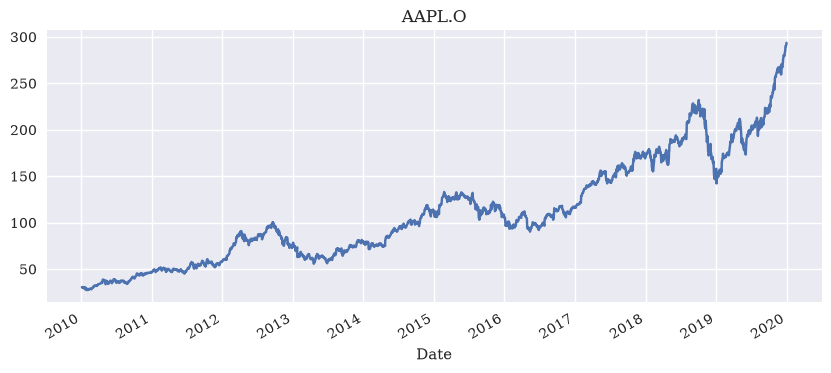

In [61]:
bb.plot_data()

预期输出：2515 条记录，区间 2010-01-05 至 2019-12-31，两列 `price` 与 `return`；最后一行为 2019-12-31，价格 293.65，对数收益率 0.007280。

## 4. 动手试验：下单与平仓

用一个新实例手动走一遍"买入 → 卖出 → 平仓"，观察现金、持仓与净资产的变化（默认 `verbose=True`，逐步打印日志）。

这里在第 0 根 K 线买入，第 100 根卖出一半，最后一根 K 线平仓。

同时把各时点状态写入 `records`，并把持仓期间的每日盯市净资产写入 `wealth`，供下一节画图。

In [62]:
def snapshot(bt, bar, event):
    '''记录某一时点的现金、持仓、价格与净资产。'''
    date, price = bt.get_date_price(bar=bar)
    return {
        'event': event,
        'bar': bar,
        'date': date,
        'price': price,
        'cash': bt.amount,
        'units': bt.units,
        'net_wealth': bt.amount + bt.units * price,
    }


def fill_daily_wealth(bt, start_bar, end_bar, wealth):
    '''在持仓不变的区间内，按每日收盘价写入净资产到 wealth。

    净资产 = 当前现金 bt.amount + 持仓 bt.units × 当日价格。
    用于两次成交之间补全曲线，供后面画图。
    '''
    for bar in range(start_bar, end_bar + 1):
        price = bt.data.price.iloc[bar]
        wealth.iloc[bar] = bt.amount + bt.units * price

In [63]:
bb = BacktestBase(
    symbol='AAPL.O',
    start='2010-1-1',
    end='2019-12-31',
    amount=10000,
    ftc=1.0,          # 每笔固定成本
    ptc=0.005,        # 每笔比例成本
)

In [64]:
last = len(bb.data) - 1
wealth = pd.Series(index=bb.data.index, dtype=float)
records = [snapshot(bb, bar=0, event='start')]

In [65]:
bb.place_buy_order(bar=0, amount=5000)  # 用 5000 美元买入
records.append(snapshot(bb, bar=0, event='buy'))
fill_daily_wealth(bb, start_bar=0, end_bar=99, wealth=wealth)

2010-01-05 | buying 163 units at 30.63
2010-01-05 | current balance 4982.05
2010-01-05 | current net wealth 9974.04


In [66]:
units_half = bb.units // 2
bb.place_sell_order(bar=100, units=units_half)  # 卖出一半持仓
records.append(snapshot(bb, bar=100, event='sell_half'))
fill_daily_wealth(bb, start_bar=100, end_bar=last - 1, wealth=wealth)

2010-05-28 | selling 81 units at 36.70
2010-05-28 | current balance 7938.66
2010-05-28 | current net wealth 10947.82


In [67]:
bb.close_out(bar=last)  # 在最后一根 K 线平仓并打印绩效
records.append(snapshot(bb, bar=last, event='close_out'))
wealth.iloc[last] = bb.amount  # 已平仓，净资产=现金
log = pd.DataFrame(records)
print(log.to_string(index=False))

2019-12-31 | inventory 0 units at 293.65
Final balance   [$] 32017.96
Net Performance [%] 220.18
Trades Executed [#] 3.00
    event  bar       date      price         cash  units   net_wealth
    start    0 2010-01-05  30.625684 10000.000000      0 10000.000000
      buy    0 2010-01-05  30.625684  4982.053631    163  9974.040068
sell_half  100 2010-05-28  36.697106  7938.656902     82 10947.819607
close_out 2514 2019-12-31 293.650000 32017.956902      0 32017.956902


## 5. 可视化

原书到此主要靠文字日志。下面把 `price` 与每日盯市 `net wealth` 画在同一张图上：左轴是股价，右轴是净资产（twin y-axis），并标出交易时点。

持仓不变时两条曲线形状接近（净资产 = 现金 + units × 价格）；差别主要来自仓位变化与交易成本。


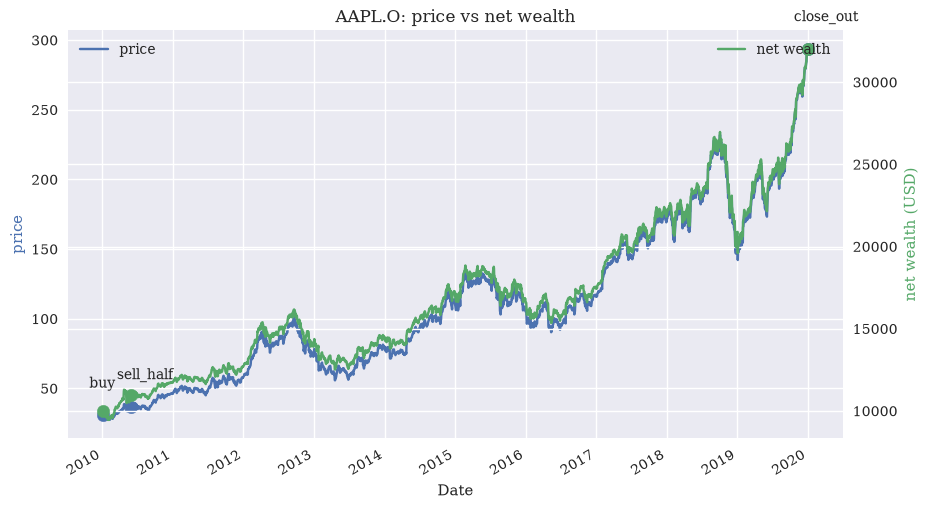

In [70]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

bb.data['price'].plot(ax=ax1, color='C0', label='price')
wealth.plot(ax=ax2, color='C1', label='net wealth')

for _, row in log[log['event'] != 'start'].iterrows():
    t = pd.Timestamp(row['date'])
    ax1.scatter(t, row['price'], s=80, color='C0', zorder=5)
    ax2.scatter(t, row['net_wealth'], s=80, color='C1', zorder=5)
    ax1.annotate(row['event'], xy=(t, row['price']),
                 xytext=(-10, 20), textcoords='offset points')

ax1.set_ylabel('price', color='C0')
ax2.set_ylabel('net wealth (USD)', color='C1')
ax1.set_title(f'{bb.symbol}: price vs net wealth')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


## 小结

- 面向对象的方式让我们能以**非冗余、易维护**的形式，搭建可服务于各类算法交易策略的基础回测设施；
- 基类还可以方便地扩展，为其上的各个子类默认提供更多功能；
- 接下来的两节将基于 `BacktestBase`，分别实现**仅做多**与**多空**回测类，由于复用了基类，回测逻辑的实现会相当简洁。